# Demo experiment, May 4, Francesco Braicovich

**Trait:** politeness  
**Model:** `google/gemma-2-2b` (base, completion)  
**Layer:** 13, central (there are 26 layers in total)  
**Data:** accepted paraphrases from the smoke-test run (`output/politeness/accepted.jsonl`)

Unlike Bettineschi's notebook (which used hand-written single-sentence prompts), this notebook
loads the LLM-generated ordinal paraphrases produced by the data generation pipeline and checks
whether the low → mid → high politeness ladder leaves a linear trace in activation space.

In [ ]:
import json
import sys
from pathlib import Path

import torch

sys.path.insert(0, str(Path("..").resolve()))  # src/notebooks/ -> src/

from lib.data_typing import Sample, LEVELS, load_accepted
from lib.representations import load_model, extract_activations, extract_activations_multilayer
from lib.analysis import compute_difference_vectors, similarity_matrix, plot_similarity_matrix

In [ ]:
MODEL   = "google/gemma-2-2b"
LAYER   = 13
TRAIT   = "politeness"
ACCEPTED_JSONL = Path("../../data/v1/politeness/accepted.jsonl")

In [ ]:
records_raw = []
with ACCEPTED_JSONL.open() as f:
    for line in f:
        line = line.strip()
        if line:
            records_raw.append(json.loads(line))

found = {r["level"] for r in records_raw}
levels_present = [l for l in LEVELS if l in found]
print(f"Loaded {len(records_raw)} accepted paraphrases")
print(f"Levels found (ordered): {levels_present}")
for lvl in levels_present:
    texts = [r["text"] for r in records_raw if r["level"] == lvl]
    print(f"  {lvl}: {len(texts)} items — e.g. '{texts[0][:80]}'")

Loaded 576 accepted paraphrases
Levels found (ordered): ['low', 'mid', 'high']
  low: 192 items — e.g. 'Unfortunately, I missed the assignment deadline and take full responsibility.'
  mid: 192 items — e.g. 'I regret missing the assignment deadline and understand the inconvenience caused'
  high: 192 items — e.g. 'I sincerely regret missing the assignment deadline and greatly appreciate your p'


In [ ]:
samples = load_accepted(ACCEPTED_JSONL)
TRAITS_CFG = [{"name": TRAIT, "intensities": levels_present}]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"device: {device}")

device: mps


In [ ]:
# slow — run once
model, tokenizer = load_model(MODEL, device)

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

In [ ]:
activations = extract_activations(samples, model, tokenizer, LAYER, device)

for (trait, intensity, scenario_id), vec in activations.items():
    print(f"  ({trait}, {intensity}, {scenario_id}): shape={vec.shape}, norm={vec.norm():.2f}")

  (politeness, low, politeness-apology-006): shape=torch.Size([2304]), norm=150.78
  (politeness, mid, politeness-apology-006): shape=torch.Size([2304]), norm=144.46
  (politeness, high, politeness-apology-006): shape=torch.Size([2304]), norm=148.89
  (politeness, low, politeness-apology-008): shape=torch.Size([2304]), norm=146.23
  (politeness, mid, politeness-apology-008): shape=torch.Size([2304]), norm=149.69
  (politeness, high, politeness-apology-008): shape=torch.Size([2304]), norm=144.54
  (politeness, low, politeness-apology-023): shape=torch.Size([2304]), norm=138.19
  (politeness, mid, politeness-apology-023): shape=torch.Size([2304]), norm=135.93
  (politeness, high, politeness-apology-023): shape=torch.Size([2304]), norm=135.72
  (politeness, low, politeness-apology-024): shape=torch.Size([2304]), norm=146.06
  (politeness, mid, politeness-apology-024): shape=torch.Size([2304]), norm=138.33
  (politeness, high, politeness-apology-024): shape=torch.Size([2304]), norm=139.09


In [ ]:
diffs = compute_difference_vectors(activations, TRAITS_CFG)

for (trait, lo, hi), vec in diffs.items():
    print(f"  {trait}: {lo} -> {hi}  norm={vec.norm():.2f}")

  politeness: mid -> high  norm=11.90
  politeness: low -> mid  norm=7.83
  politeness: low -> high  norm=16.88


In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

labels, matrix = similarity_matrix(diffs)

print("Cosine similarity matrix:")
header = f"{'':>25}" + "".join(f"{l:>27}" for l in labels)
print(header)
for i, li in enumerate(labels):
    row = f"{li:>25}" + "".join(f"{matrix[i, j]:>27.4f}" for j in range(len(labels)))
    print(row)

if len(labels) >= 2:
    print(f"\nKey number — cosine similarity {labels[0]} vs {labels[1]}: {matrix[0, 1]:.4f}")
    print("  +1 = same direction (linear), -1 = opposite, ~0 = unrelated")

Cosine similarity matrix:
                                 politeness:high-mid         politeness:mid-low        politeness:high-low
      politeness:high-mid                     1.0000                     0.4402                     0.9092
       politeness:mid-low                     0.4402                     1.0000                     0.7741
      politeness:high-low                     0.9092                     0.7741                     1.0000

Key number — cosine similarity politeness:high-mid vs politeness:mid-low: 0.4402
  +1 = same direction (linear), -1 = opposite, ~0 = unrelated


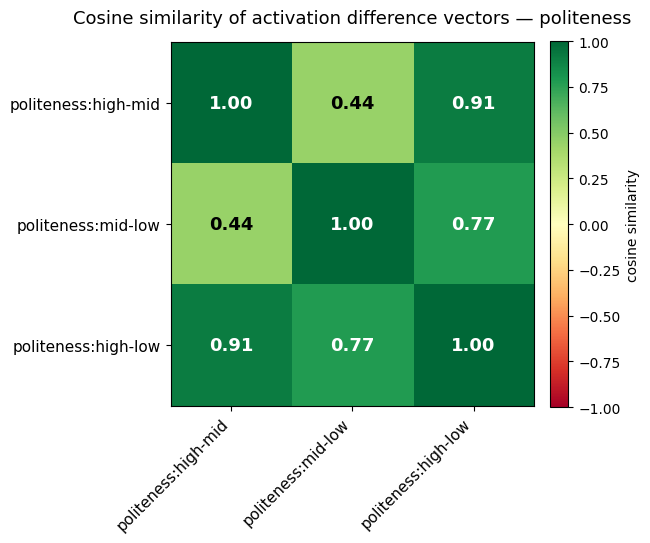

In [ ]:
n = len(labels)
cell = 2.2
fig, ax = plt.subplots(figsize=(max(6, n * cell), max(6, n * cell)))
im = ax.imshow(matrix, vmin=-1, vmax=1, cmap="RdYlGn")
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
for i, j in itertools.product(range(n), range(n)):
    color = "white" if abs(matrix[i, j]) > 0.65 else "black"
    ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
            fontsize=13, fontweight="bold", color=color)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("cosine similarity", fontsize=10)
ax.set_title(f"Cosine similarity of activation difference vectors — {TRAIT}", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

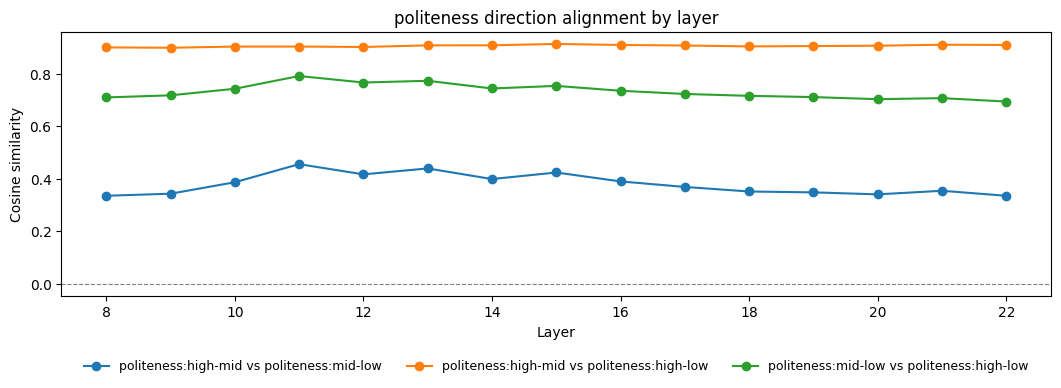

In [ ]:
sweep_layers = list(range(8, 23))

# One forward pass per batch, all layers captured at once.
acts_all = extract_activations_multilayer(samples, model, tokenizer, sweep_layers, device)

pair_indices = list(itertools.combinations(range(len(labels)), 2))
pair_sims = {pair: [] for pair in pair_indices}

for layer in sweep_layers:
    acts_layer = {(t, i, s): v for (t, i, s, l), v in acts_all.items() if l == layer}
    d = compute_difference_vectors(acts_layer, TRAITS_CFG)
    _, m = similarity_matrix(d)
    for pair in pair_indices:
        pair_sims[pair].append(m[pair[0], pair[1]])

fig, ax = plt.subplots(figsize=(11, 4.4))
for (i, j), sims in pair_sims.items():
    ax.plot(sweep_layers, sims, marker="o", linewidth=1.5, label=f"{labels[i]} vs {labels[j]}")

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title(f"{TRAIT} direction alignment by layer")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=9)
fig.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.28)
plt.show()